# Análisis de sentimiento — reseñas de Harbor House Café (WeLoveReviews)

## Objetivos

El negocio tiene un promedio de **4.5 / 5 estrellas**. La account manager quiere saber, antes de presentarle nada al cliente:

1. Qué porcentaje de las **500 reseñas escritas** se lee como **positivo, neutral o negativo**.
2. Si esa distribución **coincide** con el promedio de 4.5 estrellas.
3. Si hay diferencia, **de dónde viene**.

No vamos a entrenar nada: usaremos un modelo preentrenado de Hugging Face y validaremos sus resultados contra las estrellas reales y una revisión manual.

**Hoja de ruta:** EDA → insights → limpieza → plan y modelo → inferencia → comparación con 4.5★ → falsos negativos → revisión manual → conclusiones.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", message="IProgress not found")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", None)

# El notebook vive en src/; resolvemos la raíz del repo para que las rutas funcionen desde cualquier sitio
ROOT = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()
RAW_PATH = ROOT / "data" / "raw" / "reviews.csv"

## 1. Exploración de datos (EDA)

Empezamos por lo básico: cargar el CSV y revisar su forma y tipos de datos.

In [2]:
df = pd.read_csv(RAW_PATH)
print("Forma:", df.shape)
df.head()

Forma: (500, 3)


,review_id,rating,review_text
0,1,5,Visited Harbor House Café last weekend. Great spot to work or catch up with friends. Every dish was bursting with flavor. Worth every penny. Already planning my next visit.
1,2,5,Tried Harbor House Café after seeing it recommended online. The coffee was rich and perfectly brewed. Great spot to work or catch up with friends. Great value for what you get. Five stars without hesitation.
2,3,5,Tried Harbor House Café after seeing it recommended online. Great spot to work or catch up with friends. The seasonal menu never disappoints. Great value for what you get. Already planning my next visit.
3,4,5,Visited Harbor House Café last weekend. The staff were warm and attentive. The music and decor set the perfect mood. Worth every penny. Five stars without hesitation.
4,5,5,Grabbed a quick coffee at Harbor House Café this morning. They went out of their way to accommodate my allergy. The food was absolutely delicious. Five stars without hesitation.


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   review_id    500 non-null    int64
 1   rating       500 non-null    int64
 2   review_text  500 non-null    str  
dtypes: int64(2), str(1)
memory usage: 11.8 KB


Tres columnas, 500 filas, tipos correctos (`rating` entero, `review_text` texto). Ahora comprobamos valores faltantes y que `review_id` sea un identificador válido.

In [4]:
print("Valores faltantes por columna:")
print(df.isna().sum())
print("\nTextos vacíos:", (df["review_text"].str.strip() == "").sum())
print("review_id único:", df["review_id"].is_unique, "| rango:", df["review_id"].min(), "-", df["review_id"].max())
print("Ratings fuera de 1-5:", (~df["rating"].between(1, 5)).sum())

Valores faltantes por columna:
review_id      0
rating         0
review_text    0
dtype: int64

Textos vacíos: 0
review_id único: True | rango: 1 - 500
Ratings fuera de 1-5: 0


El dataset está completo. Veamos ahora cómo se reparten las estrellas — es la referencia contra la que compararemos el modelo.

,reseñas,%
rating,,
1,12,2.4
2,18,3.6
3,38,7.6
4,72,14.4
5,360,72.0


Promedio de estrellas: 4.50


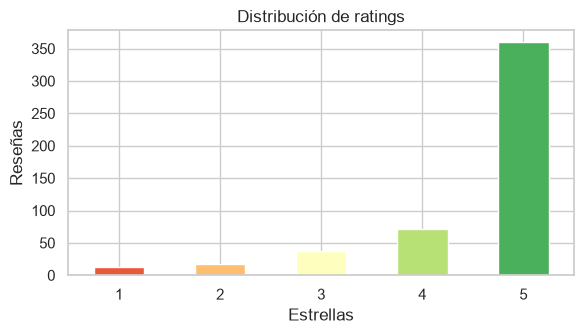

In [5]:
rating_counts = df["rating"].value_counts().sort_index()
rating_pct = (rating_counts / len(df) * 100).round(1)
display(pd.DataFrame({"reseñas": rating_counts, "%": rating_pct}))
print(f"Promedio de estrellas: {df['rating'].mean():.2f}")

ax = rating_counts.plot(kind="bar", color=sns.color_palette("RdYlGn", 5), figsize=(6, 3.5))
ax.set(title="Distribución de ratings", xlabel="Estrellas", ylabel="Reseñas")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

El promedio es exactamente 4.5 y la distribución está muy sesgada hacia 5★. Para compararla después con el modelo, la traducimos a las mismas **bandas de sentimiento** que usaremos (1–2 negativo, 3 neutral, 4–5 positivo).

In [6]:
def stars_to_band(stars: int) -> str:
    if stars <= 2:
        return "negativo"
    if stars == 3:
        return "neutral"
    return "positivo"


BAND_ORDER = ["positivo", "neutral", "negativo"]
df["rating_band"] = df["rating"].map(stars_to_band)
(df["rating_band"].value_counts(normalize=True).reindex(BAND_ORDER) * 100).round(1).rename("% según estrellas")

rating_band
positivo    86.4
neutral      7.6
negativo     6.0
Name: % según estrellas, dtype: float64

Si el texto fuera coherente con las estrellas, esperaríamos ~86% positivo, ~8% neutral y ~6% negativo. Pasamos al texto: ¿qué tan largas son las reseñas?

,n_chars,n_words
count,500.0,500.0
mean,170.2,29.1
std,27.1,4.8
min,86.0,14.0
25%,155.0,26.0
50%,173.0,29.0
75%,189.0,32.0
max,230.0,42.0


,mean,min,max
rating,,,
1,30.2,23,39
2,26.4,16,34
3,26.8,15,35
4,30.5,19,41
5,29.2,14,42


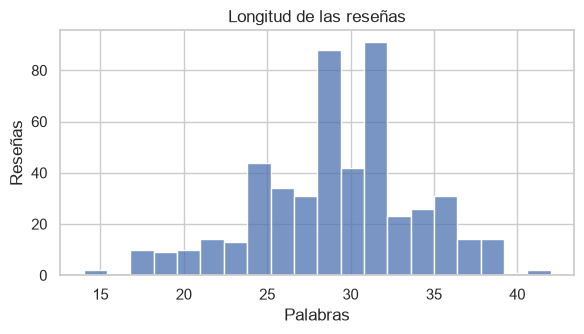

In [7]:
df["n_chars"] = df["review_text"].str.len()
df["n_words"] = df["review_text"].str.split().str.len()
display(df[["n_chars", "n_words"]].describe().round(1))
display(df.groupby("rating")["n_words"].agg(["mean", "min", "max"]).round(1))

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.histplot(df["n_words"], bins=20, ax=ax)
ax.set(title="Longitud de las reseñas", xlabel="Palabras", ylabel="Reseñas")
plt.tight_layout()
plt.show()

Reseñas cortas (14–42 palabras) y de longitud similar en todos los ratings: la longitud no distingue sentimiento y cabe holgadamente en el límite de 512 tokens de BERT. Leamos una pequeña muestra por rating.

In [8]:
df.groupby("rating", group_keys=False).sample(2, random_state=0)[["review_id", "rating", "review_text"]]

,review_id,rating,review_text
222,223,1,Came to Harbor House Café for a birthday brunch. The pastry was stale. The cashier was rude when i asked about the menu. Tables were sticky and the floor hadn't been swept. Probably won't recommend it to friends.
464,465,1,Regular customer at Harbor House Café here. The food was bland and overpriced. Our server got our order wrong twice. The place felt cramped and chaotic. Disappointing experience overall.
46,47,2,Came to Harbor House Café for a birthday brunch. The portions were way too small for the price. Our server got our order wrong twice. Probably won't recommend it to friends.
242,243,2,Stopped by Harbor House Café for the first time. The pastry was stale. Nobody checked on us the entire meal. Not sure I'll be returning.
325,326,3,"Came to Harbor House Café for a birthday brunch. The menu is fine but a bit repetitive. Average service, no complaints. Wouldn't go out of my way, but wouldn't avoid it either."
169,170,3,"Grabbed a quick coffee at Harbor House Café this morning. The food was decent, nothing special. The staff were polite but a bit slow. It's fine for a quick stop."
50,51,4,"Grabbed a quick coffee at Harbor House Café this morning. Every dish was bursting with flavor. We waited 25 minutes just to get water, but overall a solid experience. Will definitely be back!"
323,324,4,"Came to Harbor House Café for a birthday brunch. The food was absolutely delicious. We waited 25 minutes just to get water, but overall a solid experience. It's fine for a quick stop."
133,134,5,"Came to Harbor House Café for a birthday brunch. They went out of their way to accommodate my allergy. The place has such a cozy, welcoming vibe. Great value for what you get. This is now my go-to spot."
188,189,5,Tried Harbor House Café after seeing it recommended online. The music and decor set the perfect mood. Every dish was bursting with flavor. Highly recommend to anyone in the area.


Las reseñas suenan muy parecidas entre sí. Comprobamos si están construidas a partir de un conjunto reducido de frases.

In [9]:
sentences = df["review_text"].str.split(r"(?<=[.!?])\s+").explode()
print("Frases totales:", len(sentences), "| frases únicas:", sentences.nunique())
sentences.value_counts().head(10)

Frases totales: 2108 | frases únicas: 69


review_text
This is now my go-to spot.                                     92
Will definitely be back!                                       85
Five stars without hesitation.                                 84
Came to Harbor House Café for a birthday brunch.               79
Tried Harbor House Café after seeing it recommended online.    76
Already planning my next visit.                                75
Regular customer at Harbor House Café here.                    74
Grabbed a quick coffee at Harbor House Café this morning.      73
Stopped by Harbor House Café for the first time.               70
Highly recommend to anyone in the area.                        69
Name: count, dtype: int64

Solo hay **69 frases distintas** combinadas en 500 reseñas: el texto sigue plantillas. Eso explica que existan textos repetidos; veamos cuántos.

In [10]:
dups = df[df["review_text"].duplicated(keep=False)].sort_values(["review_text", "review_id"])
print("Textos duplicados (copias extra):", df["review_text"].duplicated().sum())
print("Duplicados con rating distinto:", dups.groupby("review_text")["rating"].nunique().gt(1).sum())
dups[["review_id", "rating", "review_text"]]

Textos duplicados (copias extra): 7
Duplicados con rating distinto: 0


,review_id,rating,review_text
50,51,4,"Grabbed a quick coffee at Harbor House Café this morning. Every dish was bursting with flavor. We waited 25 minutes just to get water, but overall a solid experience. Will definitely be back!"
112,113,4,"Grabbed a quick coffee at Harbor House Café this morning. Every dish was bursting with flavor. We waited 25 minutes just to get water, but overall a solid experience. Will definitely be back!"
176,177,2,Grabbed a quick coffee at Harbor House Café this morning. The food was bland and overpriced. Our server got our order wrong twice. Probably won't recommend it to friends.
194,195,2,Grabbed a quick coffee at Harbor House Café this morning. The food was bland and overpriced. Our server got our order wrong twice. Probably won't recommend it to friends.
291,292,5,Grabbed a quick coffee at Harbor House Café this morning. The music and decor set the perfect mood. Our server remembered our names by the second visit. Already planning my next visit.
483,484,5,Grabbed a quick coffee at Harbor House Café this morning. The music and decor set the perfect mood. Our server remembered our names by the second visit. Already planning my next visit.
40,41,5,Grabbed a quick coffee at Harbor House Café this morning. The sourdough bread alone is worth the visit. The team clearly cares about the customers. Will definitely be back!
107,108,5,Grabbed a quick coffee at Harbor House Café this morning. The sourdough bread alone is worth the visit. The team clearly cares about the customers. Will definitely be back!
109,110,3,"Regular customer at Harbor House Café here. Average sandwiches, nothing to write home about. The staff were polite but a bit slow. Might give it another shot."
450,451,3,"Regular customer at Harbor House Café here. Average sandwiches, nothing to write home about. The staff were polite but a bit slow. Might give it another shot."


7 pares con el mismo texto y el mismo rating, pero con `review_id` distinto. Por último, al leer la muestra aparecen frases **mixtas**: una queja seguida de un giro positivo ("..., but overall a solid experience"). Veamos dónde caen.

In [11]:
MIXED_PATTERN = r"but overall a solid experience|but honestly the food made up for it"
df["is_mixed"] = df["review_text"].str.contains(MIXED_PATTERN)
print("Reseñas mixtas:", df["is_mixed"].sum())
pd.crosstab(df["rating"], df["is_mixed"], margins=True)

Reseñas mixtas: 90


is_mixed,False,True,All
rating,,,
1,12,0,12
2,18,0,18
3,38,0,38
4,3,69,72
5,339,21,360
All,410,90,500


Las reseñas mixtas están **solo en 4–5★**, y son 69 de las 72 reseñas de 4★: el cliente se queja de algo concreto (espera, personal) pero cierra en positivo. Es justo el tipo de texto que un modelo de sentimiento puede leer mal.

### Insights clave

1. **El objetivo a igualar es claro:** promedio 4.50★ → 86.4% positivo / 7.6% neutral / 6.0% negativo si el texto acompañara a las estrellas.
2. **Las 4★ son casi todas mixtas** (69/72) y hay otras 21 mixtas en 5★: 90 reseñas (18%) contienen una queja real. Ahí es donde esperamos discrepancias modelo vs estrellas.
3. **El texto es de plantilla** (69 frases únicas). Si el modelo malinterpreta *una* frase, el error se repetirá en todas las reseñas que la contienen → conviene analizar errores **a nivel de frase**, no solo de reseña.
4. **Textos cortos y en inglés** (~29 palabras; la "é" de *Café* es el único carácter no ASCII): no hay truncado ni problemas de idioma para un BERT multilingüe.

## 2. Limpieza

**Propuesta: no hace falta limpiar.** Justificación a partir de lo visto:

- **Sin nulos, sin textos vacíos, ratings válidos e IDs únicos.**
- **Duplicados (7):** se conservan. Tienen `review_id` distinto y la plantilla hace plausible que dos clientes generen el mismo texto; además el cliente entrega 500 reseñas y el reporte debe cubrir las 500. Su peso es 1.4% y no altera la distribución.
- **Minúsculas, puntuación, acentos:** no se tocan. El modelo es *uncased* y tiene su propio tokenizador; la puntuación y el giro "but..." aportan señal de sentimiento.
- **Espacios en blanco:** comprobamos abajo que no hay espacios sobrantes al inicio o final.

In [12]:
print("Textos con espacios al inicio/final:", (df["review_text"] != df["review_text"].str.strip()).sum())
df_clean = df.copy()  # sin transformaciones: el texto llega al modelo tal cual
df_clean.shape

Textos con espacios al inicio/final: 0


(500, 7)

## 3. Plan de acción y elección del modelo

A partir de los insights:

| Insight | Acción |
|---|---|
| Distribución esperada 86 / 8 / 6 | Comparar % por banda del modelo vs bandas de estrellas, y estrellas medias predichas vs 4.5 |
| 18% de reseñas mixtas | Medir la discrepancia por separado en mixtas vs no mixtas |
| Texto de plantilla | Buscar falsos negativos y analizarlos **por frase** |
| Textos cortos, en inglés | Inferencia directa, sin truncado ni preprocesado |

**Modelo:** `nlptown/bert-base-multilingual-uncased-sentiment`, fijado a un commit concreto del Hub para que el resultado sea reproducible. Predice **1–5 estrellas**, la misma escala que el rating, lo que permite comparar directamente y mapear a bandas (1–2 negativo, 3 neutral, 4–5 positivo).

**Riesgo conocido:** se entrenó con **reseñas de productos**, no de servicios. Lo usamos igualmente y buscamos de forma explícita los falsos negativos que ese desajuste pueda producir.

## 4. Inferencia sobre las 500 reseñas

Cargamos el pipeline **una sola vez**, con el modelo fijado por nombre y `revision` (commit SHA). Los pesos se descargan a la caché local de Hugging Face, no al repositorio.

In [13]:
from transformers import pipeline
from transformers.utils import logging as hf_logging

hf_logging.disable_progress_bar()

MODEL_NAME = "nlptown/bert-base-multilingual-uncased-sentiment"
MODEL_REVISION = "8f6f4e3a8f70be4b65d3a4a8762b6d781cda240d"  # commit fijado en el Hub

sentiment_clf = pipeline("sentiment-analysis", model=MODEL_NAME, revision=MODEL_REVISION)

max_tokens = max(len(sentiment_clf.tokenizer(t)["input_ids"]) for t in df_clean["review_text"])
print(f"Reseña más larga: {max_tokens} tokens (límite del modelo: 512)")

Reseña más larga: 59 tokens (límite del modelo: 512)


Ninguna reseña se acerca al límite, así que no hay truncado. Ejecutamos el modelo en lotes y guardamos estrellas predichas, confianza y banda.

In [14]:
outputs = sentiment_clf(df_clean["review_text"].tolist(), batch_size=32, truncation=True)

df_clean["pred_stars"] = [int(o["label"].split()[0]) for o in outputs]  # etiquetas tipo "4 stars"
df_clean["pred_confidence"] = [round(o["score"], 4) for o in outputs]
df_clean["sentiment_band"] = df_clean["pred_stars"].map(stars_to_band)

print("Reseñas con predicción:", df_clean["pred_stars"].notna().sum(), "/", len(df_clean))
df_clean[["review_id", "rating", "pred_stars", "pred_confidence", "sentiment_band", "review_text"]].head()

Reseñas con predicción: 500 / 500


,review_id,rating,pred_stars,pred_confidence,sentiment_band,review_text
0,1,5,5,0.7170,positivo,Visited Harbor House Café last weekend. Great spot to work or catch up with friends. Every dish was bursting with flavor. Worth every penny. Already planning my next visit.
1,2,5,5,0.9822,positivo,Tried Harbor House Café after seeing it recommended online. The coffee was rich and perfectly brewed. Great spot to work or catch up with friends. Great value for what you get. Five stars without hesitation.
2,3,5,5,0.6623,positivo,Tried Harbor House Café after seeing it recommended online. Great spot to work or catch up with friends. The seasonal menu never disappoints. Great value for what you get. Already planning my next visit.
3,4,5,5,0.9895,positivo,Visited Harbor House Café last weekend. The staff were warm and attentive. The music and decor set the perfect mood. Worth every penny. Five stars without hesitation.
4,5,5,5,0.9829,positivo,Grabbed a quick coffee at Harbor House Café this morning. They went out of their way to accommodate my allergy. The food was absolutely delicious. Five stars without hesitation.


## 5. Desglose de sentimiento vs promedio de 4.5★

Con una predicción por reseña, comparamos el sentimiento escrito con las estrellas.

,% según estrellas,% según texto (modelo),diferencia (pp)
positivo,86.4,82.4,-4.0
neutral,7.6,8.2,0.6
negativo,6.0,9.4,3.4


Estrellas medias reales:    4.50
Estrellas medias predichas: 4.40
Misma banda que las estrellas: 95.0%
Misma estrella exacta:         85.8%


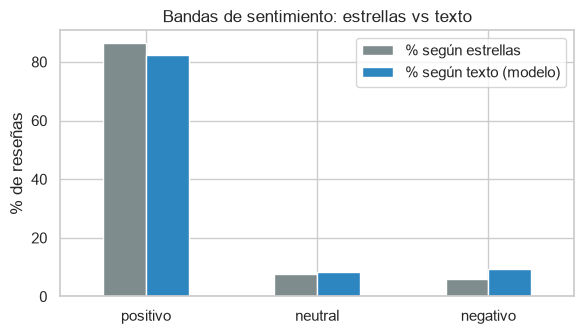

In [15]:
comparison = pd.DataFrame({
    "% según estrellas": df_clean["rating_band"].value_counts(normalize=True),
    "% según texto (modelo)": df_clean["sentiment_band"].value_counts(normalize=True),
}).reindex(BAND_ORDER).mul(100).round(1)
comparison["diferencia (pp)"] = (comparison["% según texto (modelo)"] - comparison["% según estrellas"]).round(1)
display(comparison)

print(f"Estrellas medias reales:    {df_clean['rating'].mean():.2f}")
print(f"Estrellas medias predichas: {df_clean['pred_stars'].mean():.2f}")
print(f"Misma banda que las estrellas: {(df_clean['rating_band'] == df_clean['sentiment_band']).mean():.1%}")
print(f"Misma estrella exacta:         {(df_clean['rating'] == df_clean['pred_stars']).mean():.1%}")

comparison[["% según estrellas", "% según texto (modelo)"]].plot(
    kind="bar", figsize=(6, 3.5), color=["#7f8c8d", "#2e86c1"], title="Bandas de sentimiento: estrellas vs texto"
)
plt.ylabel("% de reseñas")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

El texto es algo **menos positivo** que las estrellas (~82% vs 86%) y el negativo sube de 6% a ~9%. La matriz de confusión muestra de dónde sale esa diferencia.

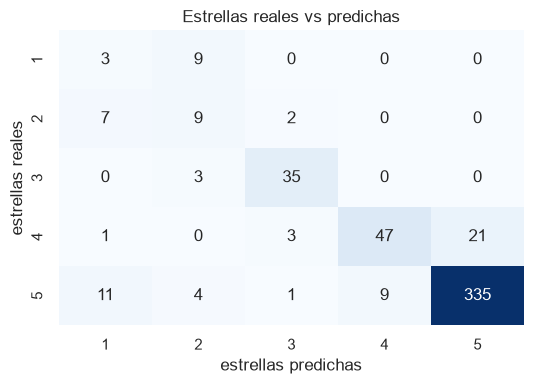

In [16]:
confusion = pd.crosstab(df_clean["rating"], df_clean["pred_stars"], rownames=["estrellas reales"], colnames=["estrellas predichas"])
fig, ax = plt.subplots(figsize=(5.5, 4))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title("Estrellas reales vs predichas")
plt.tight_layout()
plt.show()

Dos fuentes de diferencia: (a) muchas 4★ suben a 5★ o 5★ bajan a 4★ — ruido dentro de la banda positiva, irrelevante para el reporte; y (b) un grupo de **5★ que el modelo manda a 1–2★**, que sí cambia de banda. Antes de mirarlo, comprobamos si las reseñas mixtas son las culpables.

In [17]:
df_clean["band_match"] = df_clean["rating_band"] == df_clean["sentiment_band"]
display(pd.crosstab(df_clean["is_mixed"], df_clean["sentiment_band"]).reindex(columns=BAND_ORDER))
df_clean.groupby("is_mixed")["band_match"].mean().mul(100).round(1).rename("% misma banda")

sentiment_band,positivo,neutral,negativo
is_mixed,,,
False,328,37,45
True,84,4,2


is_mixed
False    95.4
True     93.3
Name: % misma banda, dtype: float64

Sorpresa: las reseñas mixtas se clasifican **igual de bien** que el resto — el modelo pondera el cierre positivo. La discrepancia está en otro sitio.

## 6. Falsos negativos

Definición: el modelo predice **1–2★** pero el cliente puso **4–5★**.

In [18]:
false_negatives = df_clean[(df_clean["pred_stars"] <= 2) & (df_clean["rating"] >= 4)]
print(f"Falsos negativos: {len(false_negatives)} ({len(false_negatives) / len(df_clean):.1%} del total)")
print(f"Confianza media en los FN: {false_negatives['pred_confidence'].mean():.2f} vs {df_clean['pred_confidence'].mean():.2f} global")
false_negatives[["review_id", "rating", "pred_stars", "pred_confidence", "is_mixed", "review_text"]]

Falsos negativos: 16 (3.2% del total)
Confianza media en los FN: 0.38 vs 0.70 global


,review_id,rating,pred_stars,pred_confidence,is_mixed,review_text
13,14,4,1,0.4443,False,Tried Harbor House Café after seeing it recommended online. Every dish was bursting with flavor. The team clearly cares about the customers. Already planning my next visit.
14,15,5,1,0.3893,False,"Every dish was bursting with flavor. The place has such a cozy, welcoming vibe. Already planning my next visit."
72,73,5,1,0.2679,False,Stopped by Harbor House Café for the first time. Service was fast and friendly. Every dish was bursting with flavor. Worth every penny. Already planning my next visit.
86,87,5,1,0.3247,False,Tried Harbor House Café after seeing it recommended online. The seasonal menu never disappoints. They went out of their way to accommodate my allergy. Will definitely be back!
137,138,5,2,0.2751,False,"Tried Harbor House Café after seeing it recommended online. They went out of their way to accommodate my allergy. The place has such a cozy, welcoming vibe. Already planning my next visit."
199,200,5,2,0.3685,False,Stopped by Harbor House Café for the first time. The music and decor set the perfect mood. Every dish was bursting with flavor. Already planning my next visit.
203,204,5,1,0.3492,True,"Came to Harbor House Café for a birthday brunch. Every dish was bursting with flavor. The cashier was rude when i asked about the menu, but honestly the food made up for it. Already planning my next visit."
253,254,5,1,0.3641,False,Stopped by Harbor House Café for the first time. They went out of their way to accommodate my allergy. Great spot to work or catch up with friends. Will definitely be back!
269,270,5,1,0.4091,False,Stopped by Harbor House Café for the first time. Our server remembered our names by the second visit. Every dish was bursting with flavor. Great value for what you get. Will definitely be back!
321,322,5,1,0.6077,True,"Every dish was bursting with flavor. The staff seemed annoyed to be there, but honestly the food made up for it. Will definitely be back!"


Leídos a mano, casi todos son **inequívocamente positivos** y solo 2 son mixtos. Como el texto es de plantilla, buscamos qué frases aparecen desproporcionadamente en estos errores.

In [19]:
positive_reviews = df_clean[df_clean["rating"] >= 4].assign(is_fn=lambda d: d["pred_stars"] <= 2)
pos_sentences = positive_reviews.assign(sentence=positive_reviews["review_text"].str.split(r"(?<=[.!?])\s+")).explode("sentence")

fn_by_sentence = pos_sentences.groupby("sentence")["is_fn"].agg(fn="sum", apariciones="count")
fn_by_sentence["% FN"] = (fn_by_sentence["fn"] / fn_by_sentence["apariciones"] * 100).round(1)
fn_by_sentence.query("fn > 0").sort_values("fn", ascending=False).head(8)

,fn,apariciones,% FN
sentence,,,
Every dish was bursting with flavor.,12,41,29.3
Already planning my next visit.,11,75,14.7
Tried Harbor House Café after seeing it recommended online.,6,68,8.8
Stopped by Harbor House Café for the first time.,6,61,9.8
Will definitely be back!,4,85,4.7
They went out of their way to accommodate my allergy.,4,38,10.5
The team clearly cares about the customers.,3,49,6.1
Service was fast and friendly.,3,56,5.4


Dos frases concentran la mayoría de los errores. Para confirmar que son las culpables, pasamos **cada frase aislada** por el modelo y vemos cuáles lee como 1–2★.

In [20]:
unique_sentences = sorted(pos_sentences["sentence"].unique())
sentence_preds = pd.DataFrame({
    "sentence": unique_sentences,
    "pred_stars": [int(o["label"].split()[0]) for o in sentiment_clf(unique_sentences, batch_size=32)],
})
sentence_preds.query("pred_stars <= 2").merge(fn_by_sentence, left_on="sentence", right_index=True)

,sentence,pred_stars,fn,apariciones,% FN
4,Every dish was bursting with flavor.,1,12,41,29.3
13,Might give it another shot.,1,0,7,0.0
14,"Nobody checked on us the entire meal, but honestly the food made up for it.",2,0,2,0.0
21,Stopped by Harbor House Café for the first time.,1,6,61,9.8
35,They went out of their way to accommodate my allergy.,1,4,38,10.5
37,Tried Harbor House Café after seeing it recommended online.,1,6,68,8.8


**Patrones y hipótesis** — el modelo fue entrenado con reseñas de **productos**, donde ciertas palabras significan problema:

- **"Every dish was bursting with flavor."** → 1★ aislada. En productos, *bursting* describe algo que revienta, se rompe o gotea; en restaurantes es un elogio. Es la frase con más falsos negativos.
- **"They went out of their way to accommodate my allergy."** → 1★. En productos, *allergy* suele ir con "me dio alergia / reacción"; aquí es atención al cliente.
- **Aperturas neutrales de visita** — *"Stopped by ... for the first time."*, *"Tried ... after seeing it recommended online."* → 1★. En reseñas de producto, "lo probé porque lo recomendaban" suele preceder a una decepción. En servicios es solo contexto.
- **"Already planning my next visit."** no es negativa sola, pero aparece mucho en los errores: frases de **intención de volver** (vocabulario de servicio) no compensan a las anteriores porque el modelo no las reconoce como elogio fuerte.
- Las quejas de servicio con giro positivo (mixtas) casi **no** causan falsos negativos: el problema es vocabulario de dominio, no la mezcla de sentimientos.
- Los FN tienen **baja confianza** (~0.38 vs ~0.7 global): un umbral de confianza permitiría marcarlos para revisión humana.

## 7. Revisión manual (20 reseñas)

Además de los errores, revisamos una muestra **aleatoria y estratificada** (4 por rating) para ver cómo se comporta el modelo en general.

In [21]:
manual_sample = (
    df_clean.groupby("rating", group_keys=False)
    .sample(4, random_state=42)
    .sort_values(["rating", "review_id"])
)

# Notas tras leer cada texto: ¿la predicción tiene sentido para un humano?
manual_notes = {
    78: "OK — porciones pequeñas y nadie atendió; negativo claro.",
    342: "OK — café quemado, caótico; negativo claro.",
    428: "OK — todo negativo; 2★ vs 1★ no cambia la banda.",
    442: "OK — cajero grosero, caótico; negativo claro.",
    148: "OK — comida sosa y pedido mal; negativo.",
    195: "OK — misma banda; 1★ es razonable por 'won't recommend'.",
    206: "OK — huevos fríos y cajero grosero; confianza baja (0.36) pero acierta.",
    339: "OK — café quemado, nadie atendió; negativo.",
    43: "OK — 'okay', 'fine', 'nothing memorable': neutral de libro.",
    162: "OK — neutral.",
    344: "OK — neutral, aunque 'order wrong twice' lo acerca a negativo.",
    480: "Discutible — rating 3★, modelo 2★. 'Staff seemed annoyed' justifica leerla negativa; error del rating más que del modelo.",
    21: "OK — positiva con queja menor; 4★ encaja.",
    116: "OK — mixta; 'wouldn't go out of my way' la deja en 4★.",
    166: "Rating dudoso — el texto dice 'Five stars without hesitation' pero el cliente puso 4★; el modelo (5★) lee mejor el texto.",
    324: "OK — mixta con cierre tibio; 4★ razonable.",
    7: "OK — muy positiva.",
    137: "OK — muy positiva.",
    144: "OK — muy positiva.",
    347: "OK — positiva; confianza menor (0.68) por 'Already planning my next visit', frase vista en los FN.",
}
manual_sample["nota_manual"] = manual_sample["review_id"].map(manual_notes)
manual_sample["misma_banda"] = manual_sample["band_match"]
manual_sample[["review_id", "rating", "pred_stars", "pred_confidence", "misma_banda", "review_text", "nota_manual"]]

,review_id,rating,pred_stars,pred_confidence,misma_banda,review_text,nota_manual
77,78,1,2,0.5029,True,Regular customer at Harbor House Café here. The portions were way too small for the price. Nobody checked on us the entire meal. Not sure I'll be returning.,OK — porciones pequeñas y nadie atendió; negativo claro.
341,342,1,2,0.5082,True,Regular customer at Harbor House Café here. The coffee tasted burnt. Nobody checked on us the entire meal. The place felt cramped and chaotic. Expected a lot more given the reviews.,"OK — café quemado, caótico; negativo claro."
427,428,1,2,0.6255,True,Regular customer at Harbor House Café here. The coffee tasted burnt. The staff seemed annoyed to be there. It was way too loud to hold a conversation. Disappointing experience overall.,OK — todo negativo; 2★ vs 1★ no cambia la banda.
441,442,1,2,0.4583,True,Visited Harbor House Café last weekend. The coffee tasted burnt. The cashier was rude when i asked about the menu. The place felt cramped and chaotic. Not sure I'll be returning.,"OK — cajero grosero, caótico; negativo claro."
147,148,2,2,0.5879,True,Tried Harbor House Café after seeing it recommended online. The food was bland and overpriced. Our server got our order wrong twice. Disappointing experience overall.,OK — comida sosa y pedido mal; negativo.
194,195,2,1,0.4770,True,Grabbed a quick coffee at Harbor House Café this morning. The food was bland and overpriced. Our server got our order wrong twice. Probably won't recommend it to friends.,OK — misma banda; 1★ es razonable por 'won't recommend'.
205,206,2,2,0.3553,True,Came to Harbor House Café for a birthday brunch. My eggs came out cold. The cashier was rude when i asked about the menu. Expected a lot more given the reviews.,OK — huevos fríos y cajero grosero; confianza baja (0.36) pero acierta.
338,339,2,2,0.5415,True,Regular customer at Harbor House Café here. The coffee tasted burnt. Nobody checked on us the entire meal. Disappointing experience overall.,"OK — café quemado, nadie atendió; negativo."
42,43,3,3,0.7821,True,"Visited Harbor House Café last weekend. The coffee was okay. Service was fine, nothing memorable. It's fine for a quick stop.","OK — 'okay', 'fine', 'nothing memorable': neutral de libro."
161,162,3,3,0.6918,True,"Visited Harbor House Café last weekend. The menu is fine but a bit repetitive. Service was fine, nothing memorable. It's fine for a quick stop.",OK — neutral.


In [22]:
print(f"Misma banda en la muestra manual: {manual_sample['misma_banda'].sum()} / {len(manual_sample)}")

Misma banda en la muestra manual: 19 / 20


En la muestra aleatoria el modelo acierta la banda en **19 de 20**. El único desacuerdo (480) es defendible, y la 166 muestra que a veces es el propio rating el que contradice al texto. Ninguno de los 16 falsos negativos cayó en la muestra: son errores concentrados en frases concretas, por eso hay que buscarlos de forma dirigida y no solo con un muestreo aleatorio.

## 8. Conclusiones

**Para la account manager, en simple:**

- **Sí, el sentimiento escrito coincide en lo esencial con las 4.5★.** El modelo lee ~82% de las reseñas como positivas, ~8% neutrales y ~9% negativas, frente a 86 / 8 / 6 según las estrellas. Sus estrellas medias (~4.4) quedan muy cerca de 4.5.
- **La diferencia (~4 puntos menos de positivas) es sobre todo error del modelo, no clientes insatisfechos.** 16 reseñas de 4–5★ claramente positivas salen como negativas porque el modelo, entrenado con reseñas de productos, malinterpreta frases típicas de restaurante ("bursting with flavor", "accommodate my allergy", "tried it after seeing it recommended").
- **Hay quejas reales que conviene contarle al cliente:** 90 reseñas positivas (18%) mencionan un problema concreto — esperas largas ("25 minutes just to get water"), personal lento o con mala actitud, pedidos equivocados. Los clientes las perdonan por la comida, pero son la principal área de mejora del servicio.
- **Recomendación operativa:** no presentar el % negativo del modelo sin revisar. Las reseñas con 1–2★ predichas y **confianza baja** deberían pasar por un humano, o probar un modelo entrenado con texto más general/de servicios.

> La salida enriquecida por reseña (estrellas predichas, confianza y banda) se genera con `python src/app.py` en `data/processed/reviews_with_sentiment.csv`.

## Addendum — ¿Hay un modelo mejor para este cliente?

Probamos `tabularisai/multilingual-sentiment-analysis` sobre las mismas 500 reseñas. Predice 5 clases (*Very Negative* … *Very Positive*) que mapeamos a las mismas tres bandas. También lo fijamos a un commit y lo cargamos una sola vez.

In [23]:
ALT_MODEL_NAME = "tabularisai/multilingual-sentiment-analysis"
ALT_MODEL_REVISION = "eea032081f8d247b4303ef3565e7cec1b6f201c9"  # commit fijado en el Hub

alt_clf = pipeline("sentiment-analysis", model=ALT_MODEL_NAME, revision=ALT_MODEL_REVISION)
print(alt_clf.model.config.id2label)

ALT_LABEL_TO_BAND = {
    "Very Negative": "negativo", "Negative": "negativo",
    "Neutral": "neutral",
    "Positive": "positivo", "Very Positive": "positivo",
}
alt_outputs = alt_clf(df_clean["review_text"].tolist(), batch_size=32, truncation=True)
df_clean["alt_label"] = [o["label"] for o in alt_outputs]
df_clean["alt_confidence"] = [round(o["score"], 4) for o in alt_outputs]
df_clean["alt_band"] = df_clean["alt_label"].map(ALT_LABEL_TO_BAND)
print("Reseñas con predicción:", df_clean["alt_band"].notna().sum(), "/", len(df_clean))

{0: 'Very Negative', 1: 'Negative', 2: 'Neutral', 3: 'Positive', 4: 'Very Positive'}


Reseñas con predicción: 500 / 500


Comparamos ambos modelos contra las estrellas con las mismas métricas de antes.

In [24]:
def model_summary(band_col):
    fn = (df_clean["rating"] >= 4) & (df_clean[band_col] == "negativo")
    pct = df_clean[band_col].value_counts(normalize=True).reindex(BAND_ORDER, fill_value=0).mul(100).round(1)
    return {
        "% positivo": pct["positivo"],
        "% neutral": pct["neutral"],
        "% negativo": pct["negativo"],
        "misma banda que estrellas (%)": round((df_clean[band_col] == df_clean["rating_band"]).mean() * 100, 1),
        "falsos negativos": int(fn.sum()),
        "3★ leídas como neutral": int(((df_clean["rating"] == 3) & (df_clean[band_col] == "neutral")).sum()),
    }


model_comparison = pd.DataFrame({
    "estrellas (referencia)": {
        "% positivo": comparison.loc["positivo", "% según estrellas"],
        "% neutral": comparison.loc["neutral", "% según estrellas"],
        "% negativo": comparison.loc["negativo", "% según estrellas"],
        "misma banda que estrellas (%)": 100.0,
        "falsos negativos": 0,
        "3★ leídas como neutral": int((df_clean["rating"] == 3).sum()),
    },
    "nlptown": model_summary("sentiment_band"),
    "tabularisai": model_summary("alt_band"),
})
model_comparison

,estrellas (referencia),nlptown,tabularisai
% positivo,86.4,82.4,88.8
% neutral,7.6,8.2,2.2
% negativo,6.0,9.4,9.0
misma banda que estrellas (%),100.0,95.0,90.6
falsos negativos,0.0,16.0,7.0
3★ leídas como neutral,38.0,35.0,5.0


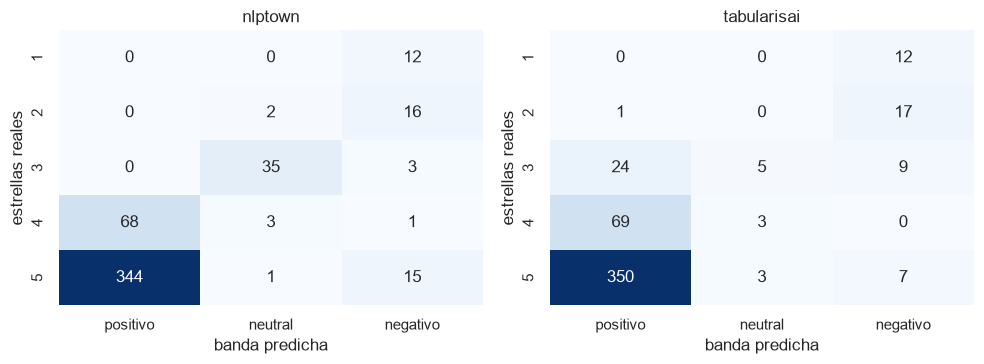

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, (col, title) in zip(axes, [("sentiment_band", "nlptown"), ("alt_band", "tabularisai")]):
    ct = pd.crosstab(df_clean["rating"], df_clean[col]).reindex(columns=BAND_ORDER, fill_value=0)
    sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set(title=title, xlabel="banda predicha", ylabel="estrellas reales")
plt.tight_layout()
plt.show()

`tabularisai` **reduce los falsos negativos a menos de la mitad**, pero a cambio **casi no usa la banda neutral**: la mayoría de las reseñas de 3★ (texto tibio: "okay", "fine", "nothing memorable") salen como positivas, y otras como negativas. ¿Qué pasó con los 16 falsos negativos de nlptown, y cuáles siguen fallando?

In [26]:
nlptown_fn = df_clean["rating"].ge(4) & df_clean["sentiment_band"].eq("negativo")
alt_fn = df_clean["rating"].ge(4) & df_clean["alt_band"].eq("negativo")

print("FN de nlptown según tabularisai:", df_clean.loc[nlptown_fn, "alt_band"].value_counts().to_dict())
print("FN de tabularisai:", alt_fn.sum(), "| también FN en nlptown:", (alt_fn & nlptown_fn).sum())
df_clean.loc[alt_fn, ["review_id", "rating", "alt_label", "alt_confidence", "pred_stars", "review_text"]]

FN de nlptown según tabularisai: {'positivo': 15, 'negativo': 1}
FN de tabularisai: 7 | también FN en nlptown: 1


,review_id,rating,alt_label,alt_confidence,pred_stars,review_text
138,139,5,Negative,0.4994,5,Tried Harbor House Café after seeing it recommended online. Great spot to work or catch up with friends. They went out of their way to accommodate my allergy. Five stars without hesitation.
219,220,5,Negative,0.4731,5,Visited Harbor House Café last weekend. They went out of their way to accommodate my allergy. Great spot to work or catch up with friends. This is now my go-to spot.
230,231,5,Negative,0.4662,5,They went out of their way to accommodate my allergy. The seasonal menu never disappoints. Great value for what you get. This is now my go-to spot.
253,254,5,Negative,0.6090,1,Stopped by Harbor House Café for the first time. They went out of their way to accommodate my allergy. Great spot to work or catch up with friends. Will definitely be back!
289,290,5,Negative,0.4001,5,Grabbed a quick coffee at Harbor House Café this morning. Best brunch i've had in months. They went out of their way to accommodate my allergy. Five stars without hesitation.
351,352,5,Very Negative,0.4740,5,They went out of their way to accommodate my allergy. The seasonal menu never disappoints. Great value for what you get. Five stars without hesitation.
414,415,5,Negative,0.3796,5,Came to Harbor House Café for a birthday brunch. They went out of their way to accommodate my allergy. Great spot to work or catch up with friends. This is now my go-to spot.


In [27]:
alt_fn_sentences = df_clean.loc[alt_fn, "review_text"].str.split(r"(?<=[.!?])\s+").explode()
alt_fn_sentences.value_counts().head(5)

review_text
They went out of their way to accommodate my allergy.    7
Great spot to work or catch up with friends.             4
Five stars without hesitation.                           3
This is now my go-to spot.                               3
The seasonal menu never disappoints.                     2
Name: count, dtype: int64

Todos los falsos negativos que quedan comparten **una sola frase: "They went out of their way to accommodate my allergy."** Ambos modelos asocian *allergy* con algo negativo; el giro "went out of their way" (elogio de servicio) no lo compensa. En cambio, `tabularisai` sí entiende "bursting with flavor" y las aperturas de visita, que eran el grueso de los errores de nlptown.

### Recomendación

**No cambiar de modelo por completo; usar `tabularisai` como segunda opinión.**

- Para la pregunta del cliente — *¿qué % es positivo, neutral, negativo?* — **nlptown es más fiable**: coincide con la banda de las estrellas en más reseñas y es el único que distingue las reseñas tibias (3★) como neutrales. Con `tabularisai` el % neutral casi desaparecería del reporte, ocultando justo las reseñas "meh" que interesan a la account manager.
- `tabularisai` es **mejor detectando elogios con vocabulario de servicio** (reduce los falsos negativos de 16 a 7).
- Combinación práctica: tomar nlptown como modelo principal y **enviar a revisión humana las reseñas donde nlptown dice negativo y tabularisai dice positivo** (son precisamente los falsos negativos de nlptown: la celda siguiente lo comprueba). Solo una reseña (254) falla en ambos modelos; contiene "allergy" y tiene confianza baja, así que la atrapa el filtro de confianza.

In [28]:
disagreements = df_clean["sentiment_band"].eq("negativo") & df_clean["alt_band"].eq("positivo")
print(f"Reseñas a revisar (nlptown negativo, tabularisai positivo): {disagreements.sum()}")
print(f"De ellas, falsos negativos reales de nlptown: {(disagreements & nlptown_fn).sum()} de {nlptown_fn.sum()}")

Reseñas a revisar (nlptown negativo, tabularisai positivo): 16
De ellas, falsos negativos reales de nlptown: 15 de 16
